# Demo of MNIST classifier in PyTorch
Code from a minimal prompt to Google AI: "pytorch classifier mnist jupyter notebook"

## One layer version

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# 1. Data Loading
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


In [7]:
# 2. Model Definition (Simple MLP)
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten image
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN()
print(model)

SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
# 3. Training Loop
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 5
for epoch in range(num_epochs):
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')



Epoch 1, Loss: 0.0385
Epoch 2, Loss: 0.1017
Epoch 3, Loss: 0.0171
Epoch 4, Loss: 0.0254
Epoch 5, Loss: 0.0929


In [5]:

# 4. Evaluation
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy on test set: {100 * correct / total:.2f}%')

Accuracy on test set: 97.91%


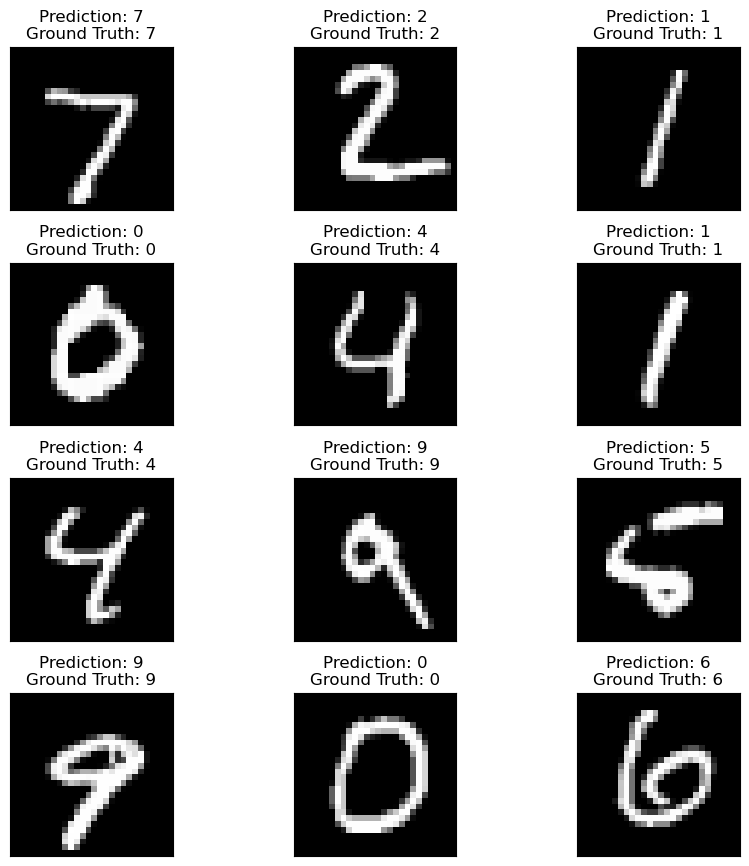

In [6]:
# Get a batch of images and labels from the test loader
examples = enumerate(test_loader)
batch_idx, (example_data, example_targets) = next(examples)

# Plot the first 6 images from the batch
num_images = 12
fig = plt.figure(figsize=(9, 9))
for i in range(num_images):
    plt.subplot(int(num_images/3), 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    
    # Make a prediction
    with torch.no_grad():
        output = model(example_data[i].unsqueeze(0))
        prediction = output.argmax(dim=1).item()

    plt.title(f"Prediction: {prediction}\nGround Truth: {example_targets[i]}")
    plt.xticks([])
    plt.yticks([])

plt.show()


## Two layer version

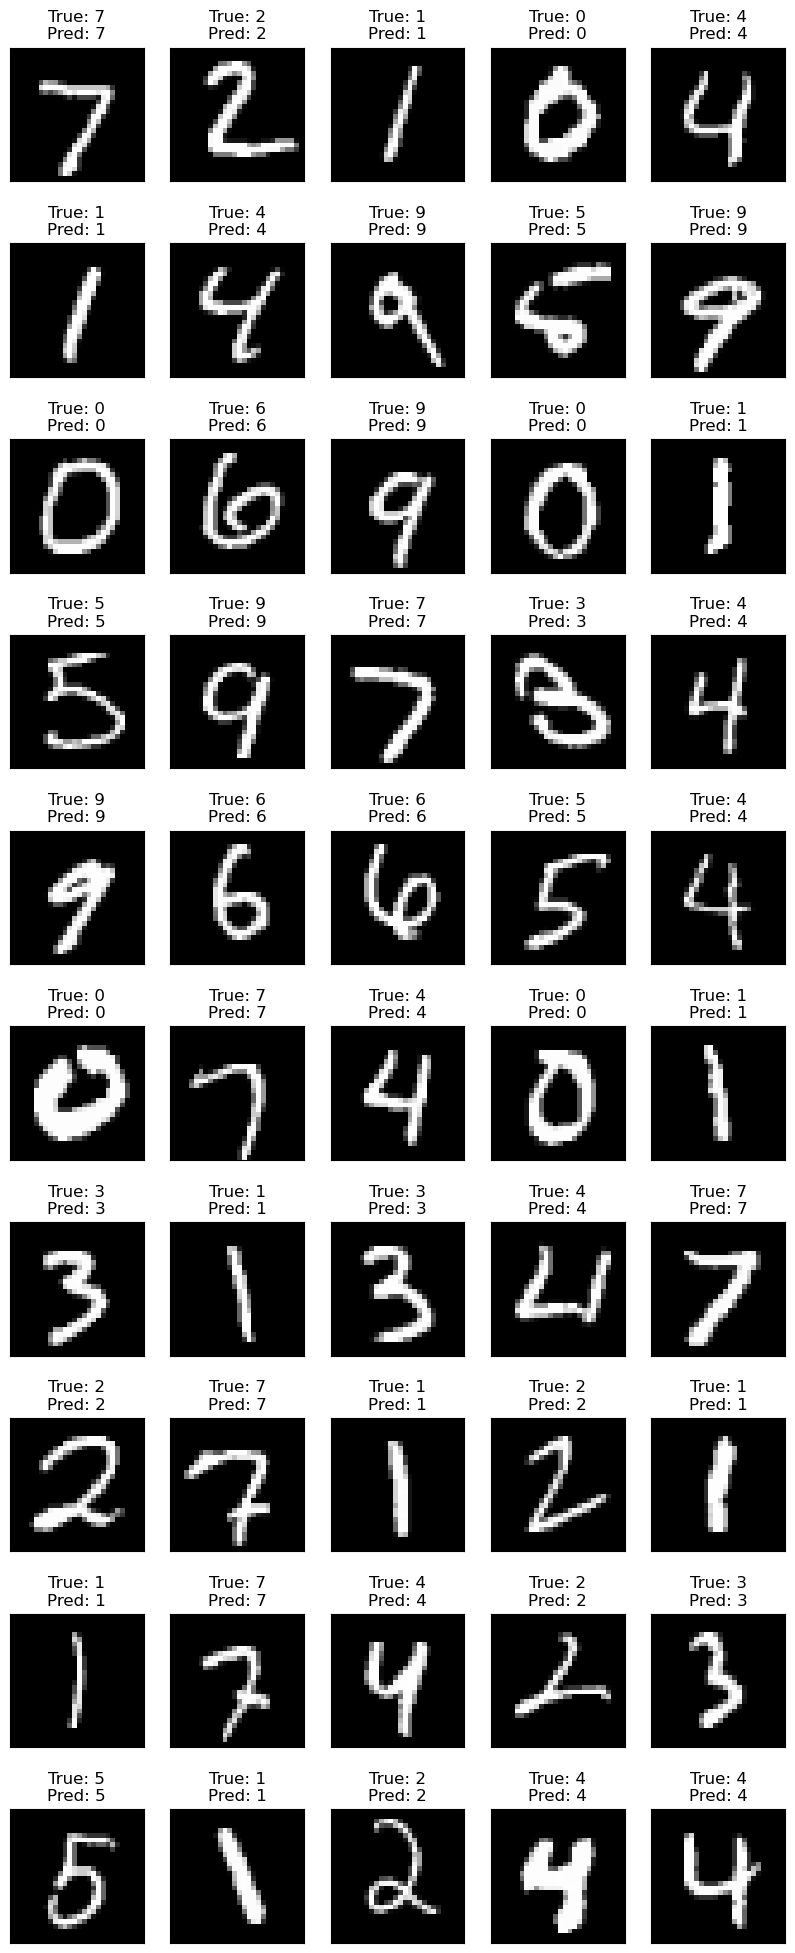

In [16]:
# Optional: Visualize a few predictions
dataiter = iter(test_loader)
images, labels = next(dataiter)

images_flat = images.reshape(-1, input_size).to(device)
outputs = model(images_flat)
_, predicted = torch.max(outputs.data, 1)

num_test = 20
num_rows = int(num_test/5)
fig = plt.figure(figsize=(10, 2 * num_rows))
for i in range(5 * num_rows):
    ax = fig.add_subplot(num_rows, 5, i + 1, xticks=[], yticks=[])
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f"True: {labels[i].item()}\nPred: {predicted[i].item()}")
plt.show()